In [ ]:
!pip install scikit-learn pandas matplotlib seaborn wordcloud nltk -q
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from google.colab import files
import nltk
nltk.download('stopwords', quiet=True)
print("Setup complete!")

Setup complete!


In [ ]:
uploaded = files.upload()  # Click "Choose Files" and select spam.csv

Saving spam.csv to spam (3).csv


In [ ]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df.iloc[:, :2]  # Keep v1 (label), v2 (message)
df.columns = ['label', 'message']
print("Dataset shape:", df.shape)
print("\nLabel distribution:\n", df['label'].value_counts())
print("\nFirst 5 rows:\n", df.head())

Dataset shape: (5572, 2)

Label distribution:
 label
ham     4825
spam     747
Name: count, dtype: int64

First 5 rows:
   label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [ ]:
stop_words = set(nltk.corpus.stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove non-letters
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['message'] = df['message'].apply(clean_text)
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
print("Preprocessing done! Sample:\n", df.head())

Preprocessing done! Sample:
    label                                            message
0      0  go jurong point crazy available bugis n great ...
1      0                            ok lar joking wif u oni
2      1  free entry wkly comp win fa cup final tkts st ...
3      0                u dun say early hor u c already say
4      0        nah dont think goes usf lives around though


In [ ]:
X = df['message']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training set shape:", X_train_tfidf.shape)
print("Test set shape:", X_test_tfidf.shape)

Training set shape: (4457, 5000)
Test set shape: (1115, 5000)


In [ ]:
models = {
    'Naive Bayes': MultinomialNB(),
    'SVM': SVC(kernel='linear'),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    trained_models[name] = model
    y_pred = model.predict(X_test_tfidf)
    print(f"{name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Naive Bayes Accuracy: 0.9650
SVM Accuracy: 0.9839
Logistic Regression Accuracy: 0.9668


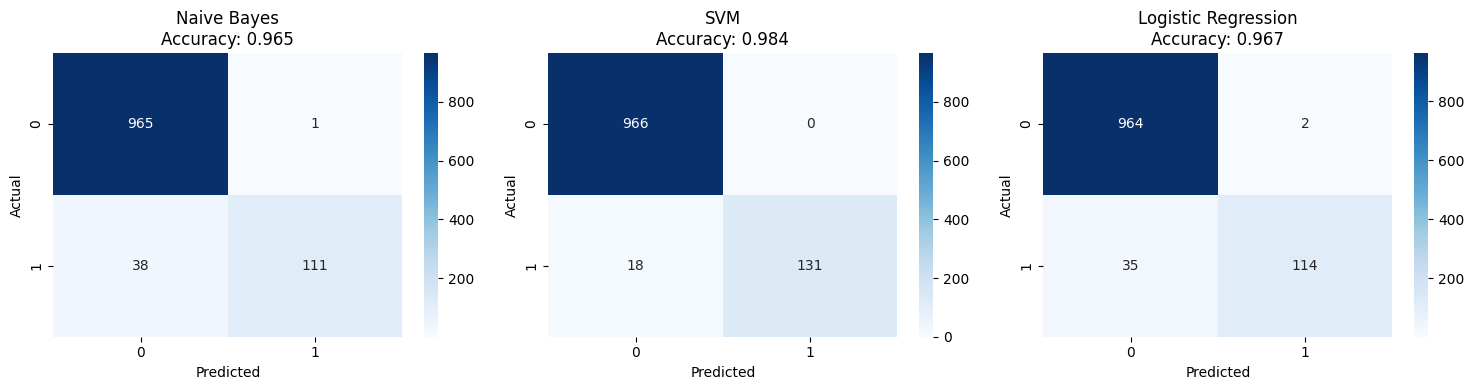

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred):.3f}')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')
plt.tight_layout()
plt.show()

In [ ]:
def predict_spam(message, model_name='Logistic Regression'):
    cleaned = clean_text(message)
    vec = vectorizer.transform([cleaned])
    pred = trained_models[model_name].predict(vec)[0]
    prob = trained_models[model_name].predict_proba(vec)[0]
    return 'SPAM' if pred == 1 else 'HAM', prob

# Test examples
print(predict_spam("Free entry to win $1000 cash!"))
print(predict_spam("Hey, meet me at the cafe later?"))

('SPAM', array([0.15598855, 0.84401145]))
('HAM', array([0.97830643, 0.02169357]))


In [ ]:
# Save your work
df.to_csv('cleaned_spam_data.csv')
from sklearn.metrics import classification_report
for name, model in trained_models.items():
    print(f"\n{name} Report:\n", classification_report(y_test, model.predict(X_test_tfidf)))


Naive Bayes Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.99      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115


SVM Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.88      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115


Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.98      0.77      0.86       149

    accuracy                           0.97      1115
   macro avg       0.97      0.88      0.92      1115
weighted